In [126]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from scipy.interpolate import griddata

import warnings
warnings.filterwarnings("ignore")

class CubedSphereData:
    def __init__(self, file_path, time=0, lev=0, variable="QV", resolution=1.0):
        """
        Handles reading, processing, interpolating, and visualizing 2D cubed-sphere data from NetCDF files.

        Parameters:
        - file_path (str): Path to the NetCDF file.
        - time (int): Time index to extract, default 0
        - lev (int): Level index to extract, default 0
        - variable (str): The variable to extract, default "QV"
        - resolution (float): Grid resolution in degrees for interpolation, default 1.0
        """
        self.file_path = file_path
        self.time = time
        self.lev = lev
        self.variable = variable
        self.resolution = resolution
        self.lats = None
        self.lons = None
        self.data = None
        self.lat_grid = None
        self.lon_grid = None
        self.data_grid = None
        self.raw_data = None
        self.raw_data_cleaned = None

        self.load_data()

    def load_data(self):
        """Reads the NetCDF file and extracts data, handling duplicate dimensions."""
        with xr.open_dataset(self.file_path, engine="h5netcdf") as ds:
            # Rename duplicate dimensions as the 'anchor' variable have duplicate dimensions - (nf, ncontact, ncontact)
            self.raw_data = ds.copy()
            anchor = ds['anchor']
            anchor_corrected = xr.DataArray(data=anchor.values, dims=('nf', 'ncontact1', 'ncontact2'), attrs=anchor.attrs)
            ds['anchor'] = anchor_corrected

            self.raw_data_cleaned = ds
            self.lats = ds["lats"].values
            self.lons = ds["lons"].values
            self.data = ds[self.variable].isel(time=self.time, lev=self.lev).values

        # Adjust longitudes
        self.lons = self.adjust_longitudes(self.lons)

        # Aggregate data from the cubed sphere
        self.all_lats, self.all_lons, self.all_data = self.aggregate_data()

    @staticmethod
    def adjust_longitudes(lons):
        """Adjusts longitudes to be within the range [-180, 180]."""
        return np.where(lons > 180, lons - 360, lons)

    def aggregate_data(self):
        """Aggregates the data across the six faces of the cubed sphere into flat lists."""
        all_lats, all_lons, all_data = [], [], []
        for face_index in range(self.data.shape[0]):  
            face_lats = self.lats[face_index, :, :].flatten()
            face_lons = self.lons[face_index, :, :].flatten()
            face_data = self.data[face_index, :, :].flatten()

            all_lats.extend(face_lats)
            all_lons.extend(face_lons)
            all_data.extend(face_data)

        return all_lats, all_lons, all_data

    def interpolate_to_latlon_grid(self):
        """Interpolates the data to a regular latitude-longitude grid."""
        lat_grid = np.arange(-90, 90 + self.resolution, self.resolution)
        lon_grid = np.arange(-180, 180 + self.resolution, self.resolution)
        lon_grid, lat_grid = np.meshgrid(lon_grid, lat_grid)

        # Perform interpolation
        #data_grid = griddata((lat_flatten, lon_flatten), data_flatten, (lat_grid, lon_grid), method='linear')
        data_grid = griddata((self.all_lats, self.all_lons), self.all_data, (lat_grid, lon_grid), method='linear')

        self.lat_grid, self.lon_grid, self.data_grid = lat_grid, lon_grid, data_grid
        return lat_grid, lon_grid, data_grid

    @staticmethod
    def plot_data(lat_grid, lon_grid, data_grid):
        """Plots the interpolated data on a latitude-longitude grid with labeled axes."""

        fig = plt.figure(figsize=(10, 5))
        ax = plt.axes(projection=ccrs.PlateCarree())
        ax.coastlines()

        contour = plt.contourf(
            lon_grid, lat_grid, data_grid * 1e3, 
            60, transform=ccrs.PlateCarree(), cmap='GnBu'
        )

        plt.colorbar(contour, label='Specific Humidity (g kg⁻¹)')
        
        # Set axis labels and ticks
        ax.set_xlabel('Longitude', fontsize=12)
        ax.set_ylabel('Latitude', fontsize=12)
        lon_ticks = range(-180, 181, 30)  # Longitude from -180 to 180, step 30°
        lat_ticks = range(-90, 91, 30)    # Latitude from -90 to 90, step 30°
        ax.set_xticks(lon_ticks)
        ax.set_yticks(lat_ticks)
        ax.set_xticklabels(lon_ticks, fontsize=10)
        ax.set_yticklabels(lat_ticks, fontsize=10)

        plt.title('Specific Humidity on Latitude-Longitude Grid', fontsize=14)
        plt.show()


In [128]:
file_path = '../data/e5303_m21c_jan18.lmv_inst_1hr_glo_C360x360x6_slv.2018-01-31T0000Z.nc4'
data_handler = CubedSphereData(file_path=file_path)

In [130]:
data_handler.raw_data

<xarray.Dataset> Size: 41MB
Dimensions:      (Xdim: 360, Ydim: 360, nf: 6, ncontact: 4, YCdim: 361,
                  XCdim: 361, lev: 1, time: 1)
Coordinates:
  * Xdim         (Xdim) float64 3kB 305.1 305.3 305.5 305.7 ... 34.48 34.69 34.9
  * Ydim         (Ydim) float64 3kB -44.9 -44.69 -44.48 ... 44.48 44.69 44.9
  * nf           (nf) int32 24B 1 2 3 4 5 6
  * ncontact     (ncontact) int32 16B 1 2 3 4
    lons         (nf, Ydim, Xdim) float64 6MB ...
    lats         (nf, Ydim, Xdim) float64 6MB ...
  * lev          (lev) float64 8B 72.0
  * time         (time) datetime64[ns] 8B 2018-01-31
Dimensions without coordinates: YCdim, XCdim
Data variables:
    contacts     (nf, ncontact) int32 96B ...
    anchor       (nf, ncontact, ncontact) int32 384B ...
    corner_lons  (nf, YCdim, XCdim) float64 6MB ...
    corner_lats  (nf, YCdim, XCdim) float64 6MB ...
    MASS         (time, nf, Ydim, Xdim) float32 3MB ...
    QV           (time, lev, nf, Ydim, Xdim) float32 3MB ...
    T            (time, lev, nf, Ydim, Xdim) float32 3MB ...
    U            (time, lev, nf, Ydim, Xdim) float32 3MB ...
    V            (time, lev, nf, Ydim, Xdim) float32 3MB ...
Attributes: (12/13)
    Comment:              NetCDF-4
    Contact:              
    Conventions:          CF
    Filename:             lmv_inst_1hr_glo_C360x360x6_slv
    History:              File written by MAPL_PFIO
    Institution:          NASA Global Modeling and Assimilation Office
    ...                   ...
    Source:               271edc7 experiment_id: e5303_m21c_jan18
    Title:                2d,1-Hourly,Instantaneous,Lowest-Model-Level,Assimi...
    additional_vars:      contacts,orientation,anchor
    file_format_version:  2.92
    grid_mapping_name:    gnomonic cubed-sphere
    gridspec_file:        C360_gridspec.nc4

In [132]:
data_handler.raw_data_cleaned

<xarray.Dataset> Size: 41MB
Dimensions:      (Xdim: 360, Ydim: 360, nf: 6, ncontact: 4, ncontact1: 4,
                  ncontact2: 4, YCdim: 361, XCdim: 361, lev: 1, time: 1)
Coordinates:
  * Xdim         (Xdim) float64 3kB 305.1 305.3 305.5 305.7 ... 34.48 34.69 34.9
  * Ydim         (Ydim) float64 3kB -44.9 -44.69 -44.48 ... 44.48 44.69 44.9
  * nf           (nf) int32 24B 1 2 3 4 5 6
  * ncontact     (ncontact) int32 16B 1 2 3 4
    lons         (nf, Ydim, Xdim) float64 6MB 305.1 305.3 305.5 ... 34.79 35.0
    lats         (nf, Ydim, Xdim) float64 6MB -35.22 -35.31 ... -35.46 -35.36
  * lev          (lev) float64 8B 72.0
  * time         (time) datetime64[ns] 8B 2018-01-31
Dimensions without coordinates: ncontact1, ncontact2, YCdim, XCdim
Data variables:
    contacts     (nf, ncontact) int32 96B ...
    anchor       (nf, ncontact1, ncontact2) int32 384B 360 360 1 ... 1 360 360
    corner_lons  (nf, YCdim, XCdim) float64 6MB ...
    corner_lats  (nf, YCdim, XCdim) float64 6MB ...
    MASS         (time, nf, Ydim, Xdim) float32 3MB ...
    QV           (time, lev, nf, Ydim, Xdim) float32 3MB ...
    T            (time, lev, nf, Ydim, Xdim) float32 3MB ...
    U            (time, lev, nf, Ydim, Xdim) float32 3MB ...
    V            (time, lev, nf, Ydim, Xdim) float32 3MB ...
Attributes: (12/13)
    Comment:              NetCDF-4
    Contact:              
    Conventions:          CF
    Filename:             lmv_inst_1hr_glo_C360x360x6_slv
    History:              File written by MAPL_PFIO
    Institution:          NASA Global Modeling and Assimilation Office
    ...                   ...
    Source:               271edc7 experiment_id: e5303_m21c_jan18
    Title:                2d,1-Hourly,Instantaneous,Lowest-Model-Level,Assimi...
    additional_vars:      contacts,orientation,anchor
    file_format_version:  2.92
    grid_mapping_name:    gnomonic cubed-sphere
    gridspec_file:        C360_gridspec.nc4

In [134]:
print("Min:", np.nanmin(data_handler.data), "Max:", np.nanmax(data_handler.data))

Min: 1.4524915e-06 Max: 0.022552734


In [136]:
lat_grid, lon_grid, data_grid = data_handler.interpolate_to_latlon_grid()

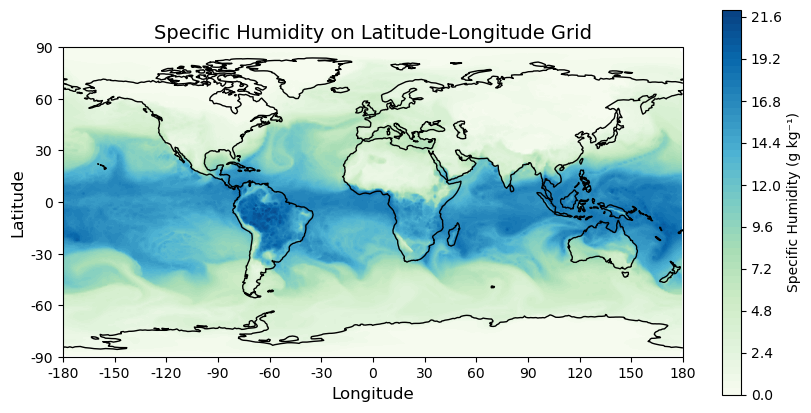

In [137]:
data_handler.plot_data(lat_grid, lon_grid, data_grid)